# 01 · Python en VS Code: solo lo que usa el proceso gaussiano

**Objetivo (30 min):** que puedas leer el notebook `02_proceso_gaussiano_desde_cero.ipynb` sin que la sintaxis te estorbe.
Cada ejemplo de aquí es una línea que aparece, tal cual, en ese notebook. No hay nada más.

| Acción en VS Code | Cómo |
|---|---|
| Ejecutar una celda | `Shift + Enter` (ejecuta y pasa a la siguiente) |
| Ver qué contiene una variable | `print(variable)` o escríbela sola al final de la celda |
| Reiniciar si todo se enredó | botón *Restart* y vuelve a ejecutar desde la primera celda |

## 1. Importar librerías y guardar números en variables (5 min)

`np` y `plt` son los apodos que usa todo el mundo. Los hiperparámetros del kernel se guardan en variables; un f-string mete variables dentro de un texto.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
AZUL, ORO, GRIS = "#003D79", "#D59F0F", "#8A8F98"   # colores; un texto entre comillas es un string
plt.rcParams.update({"figure.figsize": (9, 4), "axes.spines.top": False, "axes.spines.right": False, "font.size": 11})

ell     = 5.0      # días   (un decimal)
sigma_n = 2.5      # MW
n       = 200      # puntos de la malla (un entero)
dias    = 35
print(f"ℓ = {ell:.1f} días, σ_n = {sigma_n} MW, n = {n}")     # :.1f = un decimal

ℓ = 5.0 días, σ_n = 2.5 MW, n = 200


## 2. Arreglos de NumPy: la serie de demanda (7 min)

Un arreglo es una lista de números que opera **toda a la vez**: la fórmula se aplica a los 35 días de golpe. Así se construye la serie del notebook 02.

In [2]:
t = np.arange(dias, dtype=float)                      # 0, 1, 2, ..., 34
tendencia = 120 + 25 / (1 + np.exp(-(t - 14) / 4))    # una fórmula sobre todo el arreglo
vaiven    = 5 * np.sin(2 * np.pi * t / 14)
rng   = np.random.default_rng(30)                     # números aleatorios con semilla: siempre los mismos
ruido = rng.normal(0, 2.5, dias)                      # 35 números normales, media 0, desviación 2.5
y     = tendencia + vaiven + ruido                    # sumar arreglos = elemento a elemento

print("tamaño:", y.shape)
print("promedio :", y.mean(), " desviación:", y.std())
print("primer día:", y[0], " último:", y[-1])          # Python cuenta desde 0; -1 es el último
print("días 12 a 14:", y[12:15])                       # del índice 12 al 14 (el 15 no entra)

tamaño: (35,)
promedio : 135.2854007000195  desviación: 8.933779312218386
primer día: 124.66940862670423  último: 144.31353382997875
días 12 a 14: [126.75724947 129.05001552 134.12814825]


## 3. Máscaras booleanas: qué días observamos (5 min)

En el notebook 02 se esconden la próxima semana y tres días de medidor descompuesto con un arreglo de `True`/`False`.

In [3]:
observado = np.ones(len(t), dtype=bool)   # 35 valores True
observado[28:] = False                    # días 28..34: la próxima semana
observado[12:15] = False                  # días 12, 13, 14: medidor descompuesto

X, Y = t[observado], y[observado]         # solo los días True
print(f"{len(X)} días observados, {(~observado).sum()} sin dato")   # ~ invierte la máscara

x = np.linspace(0, 34, n)                 # n puntos igualmente espaciados: la malla donde predecimos
print("otras que aparecen:", np.full(3, 7.5), np.eye(2), np.diag(np.eye(2) * 4), np.sqrt(np.array([4.0, 9.0])))

25 días observados, 10 sin dato
otras que aparecen: [7.5 7.5 7.5] [[1. 0.]
 [0. 1.]] [4. 4.] [2. 3.]


## 4. Funciones y broadcasting: el kernel (6 min)

`def` empaqueta una receta. El kernel del notebook 02 recibe dos arreglos y devuelve una **matriz** con el parecido entre todos los pares de días.
La línea rara es `a[:, None] - c[None, :]`: convierte `a` en columna y, al restarle la fila `c`, NumPy produce la tabla de todas las diferencias.

In [4]:
a = np.array([0., 1., 2.])
c = np.array([0., 5.])
print(a[:, None] - c[None, :])       # tabla 3 x 2: fila i, columna j = a[i] - c[j]

sigma_f = Y.std()
def k(a, c):
    # Kernel RBF entre todos los pares de días de `a` y de `c`. Devuelve una matriz len(a) x len(c).
    return sigma_f**2 * np.exp(-0.5 * (a[:, None] - c[None, :])**2 / ell**2)

K = k(X, X)
print("forma de k(X, X):", K.shape, "  diagonal = σ_f² =", round(K[0, 0], 2))

[[ 0. -5.]
 [ 1. -4.]
 [ 2. -3.]]
forma de k(X, X): (25, 25)   diagonal = σ_f² = 68.52


## 5. Matrices: `@`, `.T`, `cholesky` y `solve` (5 min)

`*` multiplica elemento por elemento; `@` es el producto matricial; `.T` transpone. Cholesky es la "raíz cuadrada" de una matriz y `solve` resuelve un sistema sin invertir. Las seis líneas del notebook 02 usan solo esto.

In [5]:
A = np.array([[4., 1.],
              [1., 3.]])
v = np.array([1., 2.])
print("A * 2 =", (A * 2).tolist())            # elemento a elemento
print("A @ v =", A @ v)                       # producto matricial: [4*1+1*2, 1*1+3*2]
print("A.T   =", A.T.tolist())

L = np.linalg.cholesky(A)                    # L @ L.T == A
print("L @ L.T =", np.round(L @ L.T, 10).tolist())
sol = np.linalg.solve(A, v)                  # resuelve A @ sol = v
print("solución:", sol, " comprobación:", A @ sol)

A * 2 = [[8.0, 2.0], [2.0, 6.0]]
A @ v = [6. 7.]
A.T   = [[4.0, 1.0], [1.0, 3.0]]
L @ L.T = [[4.0, 1.0], [1.0, 3.0]]
solución: [0.09090909 0.63636364]  comprobación: [1. 2.]


## 6. Gráficas con matplotlib (5 min)

Las cuatro órdenes que usa el notebook 02: `plot`, `fill_between` (la banda), `axvspan` (las franjas) y `legend`.

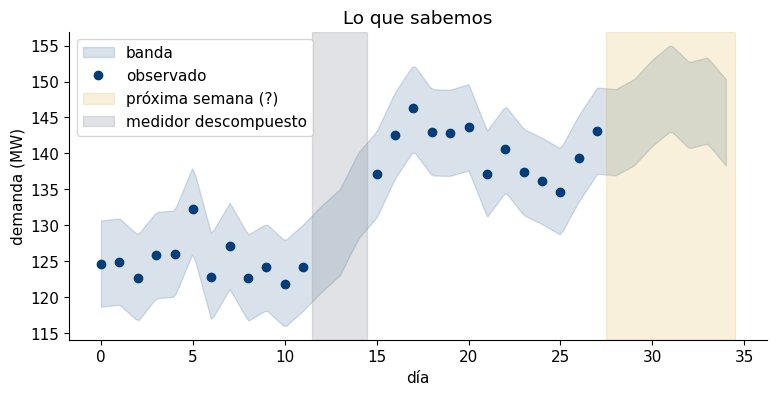

In [6]:
banda = 2 * np.full(n, 3.0)                   # una banda inventada de ±6 MW solo para ver cómo se dibuja
plt.fill_between(x, np.interp(x, t, y) - banda, np.interp(x, t, y) + banda, color=AZUL, alpha=0.15, label="banda")
plt.plot(X, Y, "o", color=AZUL, label="observado")             # "o" = puntos sin línea
plt.axvspan(27.5, 34.5, color=ORO, alpha=0.15, label="próxima semana (?)")   # alpha = transparencia
plt.axvspan(11.5, 14.5, color=GRIS, alpha=0.25, label="medidor descompuesto")
plt.xlabel("día"); plt.ylabel("demanda (MW)"); plt.legend(loc="upper left"); plt.title("Lo que sabemos")
plt.show()

## 7. Errores que verás (2 min)

| Error | Causa típica | Arreglo |
|---|---|---|
| `NameError: name 'np' is not defined` | No ejecutaste la celda del `import` | Ejecuta las celdas en orden desde arriba |
| `IndexError: index 35 is out of bounds` | Pediste un elemento que no existe (empieza en 0) | Revisa el índice |
| `ValueError: operands could not be broadcast` | Operaste arreglos de tamaños distintos | Imprime `.shape` de cada uno |
| `SyntaxError` con una flecha `^` | Falta un paréntesis o dos puntos | Mira justo donde apunta la flecha |
| `ModuleNotFoundError` | La librería no está instalada | En la terminal: `python -m pip install -r requirements.txt` |

**Listo.** Todo lo que usa `02_proceso_gaussiano_desde_cero.ipynb` ya lo viste: arreglos, máscaras, funciones, broadcasting, `@`, `cholesky`/`solve` y `fill_between`.